#Transforming Images into Cartoon, pop art, vintage, HDR and Sketch Effects

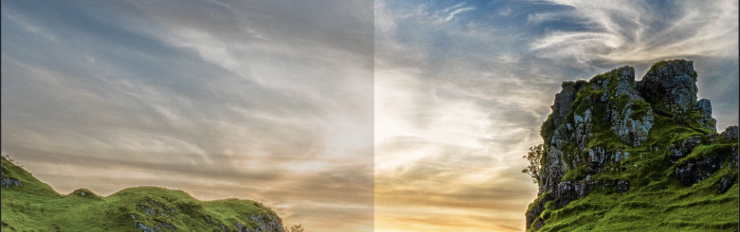  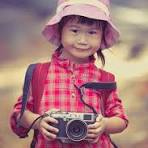 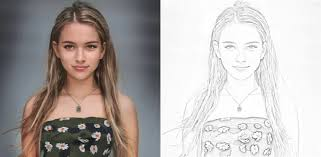 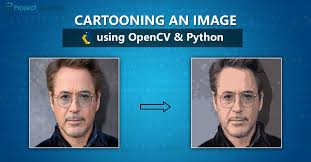 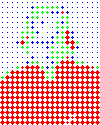

#✅REVIEW 01

#1. Problem Statement:

The challenge is to design a simple, interactive, and user-friendly web-based tool that allows users to upload an image, automatically clean it, and apply different artistic effects such as Cartoon, Pop Art, Vintage, HDR, and Sketch.

This requires effective use of edge detection, color quantization, and filtering methods to simulate artistic textures and outlines while preserving key image details.

This project aims to solve this problem by developing an interactive image processing system using Python and OpenCV, where users can load images from a local path or URL, view the original and cleaned images, and instantly apply various creative effects.
The system should provide a smooth UI, responsive buttons, download options, and image quality validation—making artistic transformations accessible to everyone without technical expertise.

#2. Objectives:

1 To allow users to **upload images** through a file path or URL with proper validation.

2 To **preprocess the input image** by removing noise using median blur and smoothing using bilateral filtering etc...

3 To **display both the original and cleaned images **for better visual comparison.

4 To **implement multiple artistic image transformations**, including:

*Cartoon Effect

*Sketch Effect

*Pop Art Effect

*Vintage Effect

*HDR Effect

5 To build an **interactive user interface** using ipywidgets with buttons for each effect.

6 To **show descriptive labels** above each output image indicating the applied effect.

7 To **support downloading** the processed image with proper filename format validation (.jpg/.jpeg/.png).

8 To **provide essential control options**, such as:

*Change Image

*Download Image

*Exit Tool

8 To ensure the **entire processing workflow** is smooth, responsive, and user-friendly for non-technical users

#3. Tools and Environment:

Programming Language: Python

Libraries: OpenCV, NumPy, Matplotlib

Environment: Google collab

#4. Expected Outcome:

A functional image transformation tool that converts input images into two distinct artistic styles — Cartoon Effect,HDR,POP ART,vintage and Pencil Sketch Effect.

#✅Review 02

#Image Preprocessing / Image Cleaning Steps (Before Cartoon & Sketch Conversion)

These are the standard steps used in image analysis to clean an image and prepare it for transformation.

**1. Read the Input Image**

User enters a path → load image.

Also convert to RGB because OpenCV loads in BGR.

In [ ]:
img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


**2. Resize the Image**

This ensures uniform processing and avoids huge images slowing the program.

In [ ]:
img = cv2.resize(img, (800, 800))


**3. Denoising (Remove Noise)**

Noise affects edges and filters.
Use Gaussian Blur or Median Blur (best for image smoothing).

In [ ]:
denoised = cv2.medianBlur(img, 5)
denoised = cv2.GaussianBlur(img, (5,5), 0)


**4. Remove Image Grain / Smooth the Image**

Use bilateral filtering (preserves edges while smoothing).

This step is VERY important for perfect cartooning.

In [ ]:
smooth = cv2.bilateralFilter(denoised, d=9, sigmaColor=75, sigmaSpace=75)


**5. Sharpen the Image (Fix Blurriness)**

Sharpening helps edges appear clearer for sketching.

In [ ]:
sharpened = cv2.filter2D(smooth, -1, kernel)


**6. Convert to Grayscale (for Edge Detection)**

This is needed by sketch and cartoon algorithms.

In [ ]:
gray = cv2.cvtColor(sharpened, cv2.COLOR_RGB2GRAY)


**7. Remove Noise from Grayscale**

This improves edge detection.

In [ ]:
gray_clean = cv2.GaussianBlur(gray, (5,5), 0)


**8. Edge Enhancement (Essential for Sketch/Cartoon)**

Use Adaptive Threshold or Canny Edge detection.

Adaptive threshold (best for cartoon edges):

In [ ]:
edges = cv2.adaptiveThreshold(gray_clean, 255,
                               cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY, 9, 9)
#Canny (optional):

edges = cv2.Canny(gray_clean, 80, 150)

#Final Preprocessed Image Output

The image is:

1 noise-free

2 smooth

3 sharpened

4 edge-ready

5 suitable for cartoon & sketch transformations

So final cartoon output is color, not grayscale.

But sketch output remains grayscale.

#✅REVIEW 3
What model we are using for “Vintage”
In our code, for the “Vintage” converter, we are using:

net = cv2.dnn.readNetFromTorch("la_muse.t7")

la_muse.t7 is a pretrained neural network for artistic style transfer, originally provided by the Fast Neural Style Transfer project.

It is trained to apply a specific painting style (“La Muse” in this case) to any input image.

So, the model transforms a image from normal → vintage look by manipulating colors, textures, and style patterns learned from the original artist dataset.

#Why only Vintage uses a model, other effects don’t
other effects:

Cartoon, Sketch, Pop Art, HDR

These effects are created using traditional image processing techniques (OpenCV filters, k-means color quantization, adaptive thresholding, etc.).

No machine learning is involved; the operations are deterministic, fast, and don’t require a pretrained model.

Vintage (style transfer)

To get an artistic or “vintage” painting effect, hand-crafting filters is hard. we need a neural network that has learned the style from examples.

That’s why you’re using a pretrained .t7 neural network.

#✅ In short:

Image processing filters → simple, rule-based, fast → used for Cartoon, Sketch, Pop Art, HDR

Neural style transfer → learned from artist datasets → used for Vintage

How the model implements the effect
The la_muse.t7 model uses Fast Neural Style Transfer, which works roughly like this:

**Step** 1: Load the model net = cv2.dnn.readNetFromTorch("la_muse.t7")

Loads a Torch-based .t7 model using OpenCV’s DNN module.

**Step 2**: Preprocess the image blob = cv2.dnn.blobFromImage(img, 1.0, (600, 600), (103.939, 116.779, 123.680), swapRB=False, crop=False)

Converts your image into a blob format that the neural network expects.

Subtracts mean values (103.939, 116.779, 123.680) which are standard preprocessing for VGG-style networks.

**Step 3**: Apply the model net.setInput(blob) output = net.forward()

Passes the image through the neural network.

The network outputs a transformed image that resembles the style it learned during training.

**Step 4**: Postprocess output = output.reshape(3, h, w).transpose(1, 2, 0) output += np.array([103.939, 116.779, 123.680]) output = np.clip(output, 0, 255).astype("uint8")

Converts the network output back to a normal RGB image.
Adds back the mean values.

Clips the values to valid RGB range (0–255).

So the model learned how to “paint” the input image in La Muse style, giving your Vintage effect.

#How the model was trained (overview)
The .t7 model is pretrained using Fast Neural Style Transfer, which is based on:

Content image: Any natural image you want to transform.

Style image: An artwork (here, the “La Muse” painting).

#Training steps:

Use a pretrained network (usually VGG-16) as a feature extractor.

Extract content features (what the image depicts) and style features (textures, colors, brush strokes) from the style image.

Define a loss function:

Content loss: Ensures output image preserves the structure of the input image.

Style loss: Ensures output image mimics the textures/colors of the style image.

Train a small feedforward network:

Network learns to map any input image → styled output image.

Trained on a large dataset (like MS-COCO) to generalize across many images.

#Result:

The network can now take any image and instantly generate a vintage/La Muse style image without retraining.

#✅ Key takeaway: Fast Neural Style Transfer creates a “one-shot” network for a specific artistic style, which is exactly what you’re using for your Vintage effect.

#Why it’s not used for other effects
Cartoon, Sketch, HDR can be implemented fully with OpenCV filters and image math → fast, no GPU needed.

Style Transfer/Vintage cannot be replicated easily with simple filters → requires a neural network trained on style examples.

So the neural network is only needed for effects that require learning from examples, like Vintage.

#✅REVIEW 4

#SOURCE CODE (GUI base)

📌 Original Image:


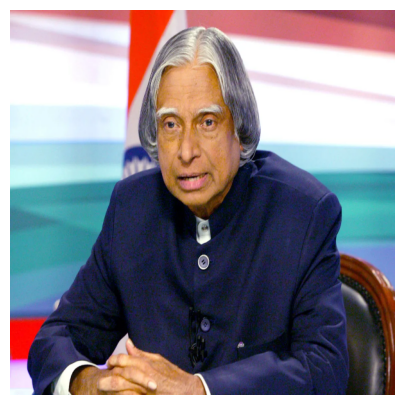

📌 Cleaned Image:


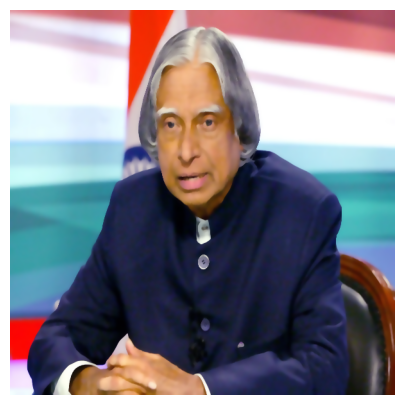

Label(value='🖼️ Vintage Image')

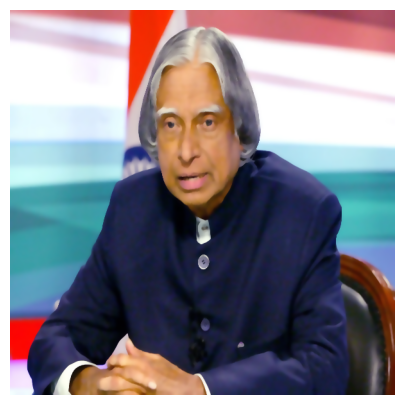

In [ ]:
# -------------------------#
# FULL IMAGE EFFECT TOOL WITH STYLE TRANSFER
# -------------------------#

from IPython.display import display, clear_output
import ipywidgets as widgets
import cv2
import numpy as np
import matplotlib.pyplot as plt
import threading
import time
import urllib.request
import re

# -------------------------
# GLOBAL VARIABLES
# -------------------------
processed_image = None
clean_image = None
original_image = None
effect_label_widget = widgets.Label(value="")  # Effect description above output

# -------------------------
# HELPER FUNCTIONS
# -------------------------
def load_image_from_path(path):
    global original_image, clean_image
    try:
        if path.startswith("http"):
            urllib.request.urlretrieve(path, "temp_img.jpg")
            img = cv2.imread("temp_img.jpg")
        else:
            img = cv2.imread(path)
        if img is None:
            print("❌ Could not read image. Check path/URL.")
            return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (600, 600))
        original_image = img.copy()
        clean_image = preprocess_image(img)
        return clean_image
    except Exception as e:
        print("❌ Error loading image:", e)
        return None

def preprocess_image(img):
    print("🕒 Image cleaning in process...")
    time.sleep(0.5)
    denoise = cv2.medianBlur(img, 3)
    smooth = cv2.bilateralFilter(denoise, 9, 75, 75)
    print("✅ Image cleaned successfully!")
    return smooth

def show(img, cmap=None):
    plt.figure(figsize=(5,5))
    if cmap:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    plt.axis('off')
    plt.show()

def show_original_and_clean():
    print("📌 Original Image:")
    show(original_image)
    print("📌 Cleaned Image:")
    show(clean_image)

# -------------------------
# POP ART DOTS
# -------------------------
def make_pop_art_dots(img, dot_size_multiplier=5):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    small_img = cv2.resize(gray, (0, 0), fx=0.1, fy=0.1, interpolation=cv2.INTER_AREA)
    output_height = small_img.shape[0] * dot_size_multiplier
    output_width = small_img.shape[1] * dot_size_multiplier
    canvas = np.full((output_height, output_width, 3), 255, dtype=np.uint8)

    color_palette = [(0,0,255),(0,255,0),(255,0,0),(0,255,255)]

    for y in range(small_img.shape[0]):
        for x in range(small_img.shape[1]):
            intensity = small_img[y, x]
            color_index = int(intensity / 255 * len(color_palette)) % len(color_palette)
            dot_color = color_palette[color_index]
            dot_radius = int((255 - intensity) / 255 * (dot_size_multiplier / 2))
            cx = x * dot_size_multiplier + dot_size_multiplier // 2
            cy = y * dot_size_multiplier + dot_size_multiplier // 2
            cv2.circle(canvas, (cx,cy), dot_radius, dot_color, -1)

    return canvas[:,:,::-1]

# -------------------------
# HDR
# -------------------------
def make_hdr(img):
    bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    hdr = cv2.detailEnhance(bgr, sigma_s=10, sigma_r=0.15)
    return cv2.cvtColor(hdr, cv2.COLOR_BGR2RGB)

# -------------------------
# OTHER EFFECTS
# -------------------------
def make_improved_cartoon(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray_blur = cv2.medianBlur(gray, 7)
    edges = cv2.adaptiveThreshold(gray_blur, 255,
                                  cv2.ADAPTIVE_THRESH_MEAN_C,
                                  cv2.THRESH_BINARY, 9, 5)
    data = np.float32(img.reshape((-1, 3)))
    k = 8
    _, labels, centers = cv2.kmeans(data, k, None,
                                    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0),
                                    10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    quantized = centers[labels.flatten()].reshape(img.shape)
    return cv2.bitwise_and(quantized, quantized, mask=edges)

def make_sketch(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    inv = 255 - gray
    blur = cv2.GaussianBlur(inv, (21, 21), 0)
    sketch = cv2.divide(gray, 255 - blur, scale=256)
    return cv2.cvtColor(sketch, cv2.COLOR_GRAY2RGB)

# -------------------------
# ⭐ NEW STYLE TRANSFER FUNCTION (vintage)
# -------------------------
def make_style_transfer(img):
    try:
        net = cv2.dnn.readNetFromTorch("la_muse.t7")
    except:
        print("❌ Model file 'shinkai.t7' not found! Place it in working directory.")
        return img

    h, w = 600, 600
    blob = cv2.dnn.blobFromImage(img, 1.0, (w, h),
                                 (103.939, 116.779, 123.680),
                                 swapRB=False, crop=False)

    net.setInput(blob)
    output = net.forward()

    output = output.reshape(3, h, w)
    output = output.transpose(1, 2, 0)
    output += np.array([103.939, 116.779, 123.680])
    output = np.clip(output, 0, 255).astype("uint8")

    return cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

# -------------------------
# WIDGETS
# -------------------------
path_box = widgets.Text(placeholder='Paste image path or URL here', layout=widgets.Layout(width='500px'))
submit_button = widgets.Button(description="✅ Submit", button_style='success')

cartoon_btn = widgets.Button(description="🖌️ Cartoon", layout=widgets.Layout(width='140px', height='40px'))
sketch_btn = widgets.Button(description="✏️ Sketch", layout=widgets.Layout(width='140px', height='40px'))
popart_btn = widgets.Button(description="🎨 Pop Art", layout=widgets.Layout(width='140px', height='40px'))
hdr_btn = widgets.Button(description="💡 HDR", layout=widgets.Layout(width='140px', height='40px'))

# 🔥 renamed Style Transfer → Vintage
style_btn = widgets.Button(description="📷 Vintage", layout=widgets.Layout(width='140px', height='40px'))

download_btn = widgets.Button(description="⬇️ Download", layout=widgets.Layout(width='120px', height='40px'))
change_btn = widgets.Button(description="🔄 Change Image", layout=widgets.Layout(width='140px', height='40px'))
exit_btn = widgets.Button(description="❌ Exit", layout=widgets.Layout(width='80px', height='40px'))

for btn in [download_btn, change_btn, exit_btn]:
    btn.layout.border='2px solid black'
    btn.layout.border_radius='5px'

bottom_box = widgets.HBox([download_btn, change_btn, exit_btn],
                          layout=widgets.Layout(border='2px solid black', padding='8px',
                                                width='420px', justify_content='space-around'))

effect_box = widgets.VBox([])

# -------------------------
# BUTTON FUNCTIONS
# -------------------------
def show_effects_gui():
    effect_box.children = [
        widgets.HBox([cartoon_btn, sketch_btn, popart_btn]),
        widgets.HBox([hdr_btn, style_btn]),  # vintage removed, style renamed
        bottom_box
    ]
    display(effect_box)

def on_submit_clicked(b):
    clear_output()
    img = load_image_from_path(path_box.value)
    if img is None:
        display(path_box, submit_button)
        return
    show_original_and_clean()
    display(effect_label_widget)
    show_effects_gui()

def apply_effect(effect_func, label):
    global processed_image
    processed_image = effect_func(clean_image)
    effect_label_widget.value = f"🖼️ {label}"
    clear_output()
    show_original_and_clean()
    display(effect_label_widget)
    show(processed_image)
    show_effects_gui()

def on_download_clicked(b):
    global processed_image
    if processed_image is None:
        print("No image to download!")
        return

    filename_widget = widgets.Text(value='outputimage.jpg', placeholder='Enter filename with extension', description='Save as:')
    save_btn = widgets.Button(description='Save ✅', button_style='success')
    error_label = widgets.Label(value="")

    def save_clicked(btn):
        filename = filename_widget.value.strip()
        if not re.match(r'.+\.(jpg|jpeg|png)$', filename, re.IGNORECASE):
            error_label.value = "❌ Invalid format! Use .jpg, .jpeg, or .png"
            return
        cv2.imwrite(filename, cv2.cvtColor(processed_image, cv2.COLOR_RGB2BGR))
        clear_output()
        show_original_and_clean()
        display(effect_label_widget)
        show(processed_image)
        show_effects_gui()
        print(f"✅ Image saved as: {filename}")

    save_btn.on_click(save_clicked)
    clear_output()
    display(filename_widget, save_btn, error_label)

def on_change_image_clicked(b):
    clear_output()
    display(path_box, submit_button)

def on_exit_clicked(b):
    clear_output()
    print("🎉 Thank you for using the Image Tool!")

# -------------------------
# CONNECT BUTTONS
# -------------------------
submit_button.on_click(on_submit_clicked)
cartoon_btn.on_click(lambda b: apply_effect(make_improved_cartoon, "Cartoon Image"))
sketch_btn.on_click(lambda b: apply_effect(make_sketch, "Sketch Image"))
popart_btn.on_click(lambda b: apply_effect(make_pop_art_dots, "Pop Art Dots Image"))
hdr_btn.on_click(lambda b: apply_effect(make_hdr, "HDR Image"))

# 🔥 "Vintage" now calls style transfer
style_btn.on_click(lambda b: apply_effect(make_style_transfer, "Vintage Image"))

download_btn.on_click(on_download_clicked)
change_btn.on_click(on_change_image_clicked)
exit_btn.on_click(on_exit_clicked)

# -------------------------
# START GUI
# -------------------------
display(path_box, submit_button)


#✅REVIEW 5

#conclusion

This project addresses the need for an intuitive web-based tool that simplifies artistic image transformations. By leveraging Python and OpenCV, it aims to empower users to easily upload images, preprocess them for optimal quality, and apply a range of creative effects, including Cartoon, Sketch, Pop Art, HDR, and Vintage styles. The core challenge involves skillfully employing image processing techniques such as edge detection, color quantization, and advanced filtering to achieve these diverse artistic textures, all while ensuring key visual details are maintained. The ultimate goal is to deliver a smooth and user-friendly experience, complete with responsive controls and download functionalities, making sophisticated image editing accessible to everyone.

#Key takeaways:

Goal: To create an interactive, user-friendly web tool for artistic image transformations.

Functionality: Upload, preprocess (denoising, smoothing), apply various artistic effects (Cartoon, Sketch, Pop Art, HDR, Vintage), display original/cleaned images, and download processed results.

Techniques: Utilizes OpenCV for traditional image processing (filters, edge detection) and a pretrained neural network model (la_muse.t7) for the Vintage (style transfer) effect.

User Experience: Emphasizes a smooth UI, responsive controls, image validation, and clear output labeling to cater to non-technical users.

Outcome: A functional tool that democratizes artistic image editing.